In [1]:
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt
import torch as tc


Consider the following Hamiltonian:

$H = B_0 \sigma_z + B_1 cos(\omega t) \sigma_x$.



/home/gubio/anaconda3/lib/python3.13/site-packages/qutip/solver/options.py:16: FutureWarning: Dedicated options class are no longer needed, options should be passed as dict to solvers.
  warnings.warn(
/home/gubio/anaconda3/lib/python3.13/site-packages/qutip/core/coefficient.py:423: UserWarning: `cython`, `setuptools` and `filelock` are required for compilation of string coefficents. Falling back on `eval`.
  warnings.warn(


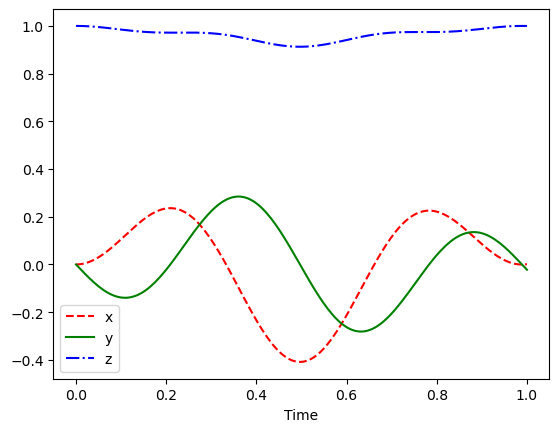

In [2]:
# Operadores de Pauli
sx = qt.sigmax()
sy = qt.sigmay()
sz = qt.sigmaz()

# Non-driving Hamiltonian
B0 = 2 * np.pi
H0 = B0 * sz

# Driving Hamiltonian
B1 = 1
w  = 2 * np.pi
H1 = B1 * sx
args = {"w": w}

# Total Hamiltonian
H = [H0, [H1, "np.cos(w*t)"]]

# Collapse operators
c_op_list = []
# Operadores para medição <O>  ->  <σx>, <σy>, <σz>
O_qobj = [sx, sy, sz]

# initial state
psi0 = qt.basis(2, 0)

# Obtain Time Evolution
tlist = np.linspace(0,1, 200)

# Solução da equação de Schrödinger / mestre
options = qt.Options(store_states=True)

result = qt.mesolve(H, psi0, tlist,
                            c_ops=c_op_list, e_ops=O_qobj, args=args, options=options)
# Extract expectation values for pauli matrices
exp_sx_circ, exp_sy_circ, exp_sz_circ = result.expect


# resutlados 
plt.plot(tlist, exp_sx_circ, "r--", label="x")
plt.plot(tlist, exp_sy_circ, "g-", label="y")
plt.plot(tlist, exp_sz_circ, "b-.", label="z")

plt.xlabel("Time")
plt.legend()
plt.show()


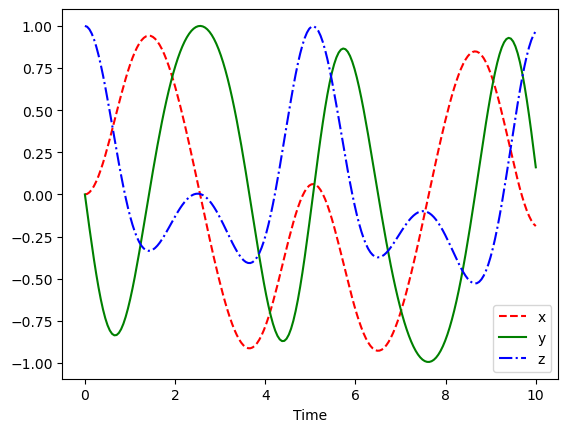

In [13]:
def data_jc(lista_J, tfinal, N, device="cpu", state=True):
    """
    Hamiltoniana dependente do tempo:
        H(t) = - B0 * sigma_y  -  B1 * cos(omega * t) * sigma_x

    lista_J = [B0, B1, omega]  (em unidades de frequência; multiplicadas por 2*pi no código)
    """

    # Operadores de Pauli
    sx = qt.sigmax()
    sy = qt.sigmay()
    sz = qt.sigmaz()

    # Non-driving Hamiltonian
    B0 = lista_J[0] * 2 * np.pi
    H0 = B0 * sz

    # Driving Hamiltonian
    B1 = lista_J[1] 
    w  = lista_J[2] * 2 * np.pi
    H1 = B1 * sx
    args = {"w": w}

    # Forma compatível com sesolve/mesolve
    H_qutip = [H0, [H1, 'cos(w * t)']]

    # Collapse operators
    c_op_list = []
    # Operadores para medição <O>  ->  <σx>, <σy>, <σz>
    O_qobj = [sx, sy, sz]

    # Solução da equação de Schrödinger / mestre
    options = qt.Options(store_states=True)

    # Obtain Time Evolution
    tlist = np.linspace(0,tfinal, N)

    psi0 = qt.basis(2, 0)
    if state:
        print("Using Schrodinger equation solver...")
        #result = qt.sesolve(H_qutip, psi0, tlist, e_ops=O_qobj, args=args, options=options)
    else:
        result = qt.mesolve(H_qutip, psi0, tlist,
                            c_ops=c_op_list, e_ops=O_qobj, args=args, options=options)

    # -----------------------
    # Construir H(t) em cada instante como matriz densa 2x2
    # -----------------------
    H_t_np = []
    for t in tlist:
        H_t = B0 * sz + B1 * np.cos(w * t) * sx
        H_t_np.append(H_t.full())

    H_t_np = np.array(H_t_np, dtype=np.complex64)   # shape (N, 2, 2)

    # Operadores de observável em forma de matriz
    O_op_np = np.array([op.full() for op in O_qobj], dtype=np.complex64)

    # Estados ao longo do tempo, achatados
    y_train_np = np.array(
        [result.states[i].full().flatten() for i in range(N)],
        dtype=np.complex64
    )

    # Valores médios <O>
    expect_np = np.array(result.expect)   # shape (n_ops, N)

    # -----------------------
    # Conversão para tensores do PyTorch
    # -----------------------
    H = tc.tensor(H_t_np, dtype=tc.complex64, device=device)      # (N, 2, 2)
    O_op = tc.tensor(O_op_np, device=device)                      # (3, 2, 2)
    y_train = tc.tensor(y_train_np, device=device)                # (N, 4)
    expect = tc.tensor(expect_np, device=device).transpose(0, 1)  # (N, 3)

    return y_train, expect, H, O_op


y_train, expect, H, O_op = data_jc([.1, 1.0, .10], tfinal=10.0, N=200, device="cpu", state=False)


tlist = np.linspace(0,10.0, 200)
# resutlados 
plt.plot(tlist, expect[:,0].numpy(), "r--", label="x")
plt.plot(tlist, expect[:,1].numpy(), "g-", label="y")
plt.plot(tlist, expect[:,2].numpy(), "b-.", label="z")

plt.xlabel("Time")
plt.legend()
plt.show()